## Task 2

Las siguientes preguntas evalúan su comprensión estratégica de la evolución de los detectores de dos 
etapas y su capacidad de tomar decisiones de arquitectura justificadas dentro del contexto operativo de 
VisorShelf. Se valorará la coherencia del argumento con las restricciones reales del sistema.

### Pregunta 2.1

El CTO de VisorShelf propone usar el detector original R-CNN (2014) para la primera versión del sistema. El 
equipo de ingeniería calcula que con el dataset actual y una CPU de tienda, cada imagen tardaría 
aproximadamente 45 segundos en procesarse. Con esto responda en su reporte: 

1. Identifique el cuello de botella principal de R-CNN que causa esa latencia. Explique por qué procesar 2,000 propuestas de región de forma independiente es computacionalmente costoso, conectando su respuesta con lo que la red hace internamente en cada pasada.

R// El principal cuello de botella de R-CNN es que procesa cada propuesta de región de forma independiente pasando cada una por la red convolucional completa. Esto implica que si hay alrededor de 2000 regiones, la CNN se ejecuta miles de veces por imagen, repitiendo cálculos sobre zonas que muchas veces se solapan. Este diseño hace que el procesamiento sea extremadamente lento, especialmente en CPU, ya que no se reutiliza información entre regiones y cada pasada implica un costo computacional alto.

2. Fast R-CNN introdujo el feature map compartido y el RoI Pooling para resolver ese cuello de botella. Explique la lógica detrás de cada uno: ¿qué cómputo elimina el feature map compartido?, ¿qué problema resuelve el RoI Pooling y qué operación matemática realiza para producir un tensor de tamaño fijo a partir de regiones de tamaño variable?

R// Fast R-CNN resuelve este problema introduciendo el concepto de feature map compartido, donde la imagen completa se procesa una sola vez por la CNN y luego las regiones se proyectan sobre ese mapa de características. Esto elimina la redundancia de cómputo. Además, el RoI Pooling permite convertir regiones de tamaño variable en tensores de tamaño fijo, dividiéndolas en una grilla y aplicando pooling, lo que hace posible conectarlas a capas fully connected sin importar su tamaño original.

3. Con Fast R-CNN el tiempo de CNN bajó a 0.3 s/imagen, pero el tiempo total seguía siendo ~2.3 s. Identifique el nuevo cuello de botella y explique por qué Selective Search representa un problema arquitectónico más profundo que simplemente ser lento.

R// A pesar de estas mejoras, el nuevo cuello de botella pasa a ser Selective Search, que sigue tomando alrededor de dos segundos por imagen. Este método no forma parte de la red ni es entrenable, por lo que no puede optimizarse junto con el modelo. Esto lo convierte en un problema más profundo que solo la velocidad, ya que limita la posibilidad de tener un sistema verdaderamente eficiente y end-to-end.

### Pregunta 2.2

El equipo de VisorShelf decide usar Faster R-CNN como base del sistema. Un ingeniero junior pregunta: "¿Por qué necesitamos una Region Proposal Network si ya tenemos el feature map? ¿No podríamos simplemente hacer sliding window directamente sobre el feature map?" 

Responda en su reporte: 

1. Responda la pregunta del ingeniero junior. Explique qué hace la RPN que un sliding window clásico no puede hacer, y por qué el hecho de que la RPN opere sobre el mismo feature map del backbone es una ventaja semántica, no solo computacional.

R// La Region Proposal Network es necesaria porque un enfoque de sliding window sería demasiado costoso y poco eficiente. El sliding window evalúa muchas regiones de forma exhaustiva sin aprender cuáles son relevantes, mientras que la RPN aprende a generar propuestas de regiones que probablemente contienen objetos. Además, al trabajar sobre el mismo feature map del backbone, no solo comparte cómputo, sino que también aprovecha información semántica más rica para hacer mejores predicciones.

2. La RPN utiliza anchor boxes predefinidos (9 por posición: 3 escalas × 3 relaciones de aspecto). Explique qué son los anchors y por qué la red predice deltas (Δx, Δy, Δw, Δh) en lugar de coordenadas absolutas. En la decodificación $w = w_a · e^{Δw}$, identifique qué representa cada símbolo y explique por qué se usa la exponencial para las dimensiones.

R// Los anchors son cajas predefinidas que sirven como referencia para que la red aprenda a ajustar bounding boxes. En lugar de predecir coordenadas absolutas, la red aprende deltas respecto a estos anchors, lo que facilita el entrenamiento porque las predicciones son más estables. En la formula 

$$ w = w_a * e^{Δw}$$

$w_a$ representa el ancho del anchor y Δw el ajuste aprendido. El uso de la exponencial permite modelar cambios de escala y asegura que las dimensiones finales sean siempre positivas.

3. Faster R-CNN logra ~5 FPS con VGG16. La restricción de VisorShelf es procesar una imagen en menos de 500 ms (≥ 2 FPS). Tomando en cuenta esa restricción, ¿recomendaría Faster R-CNN para producción en el hardware de tienda? Argumente su respuesta considerando al menos dos factores distintos a la velocidad pura (p. ej., precisión en objetos pequeños y densos, facilidad de fine-tuning, ecosistema de implementación).

R// En cuanto a Faster R-CNN, aunque ofrece buena precisión, especialmente en objetos pequeños y densos como los de un anaquel, su desempeño en CPU puede ser limitado. Dado que el sistema requiere procesar imágenes en menos de 500 ms, es posible que el modelo necesite optimizaciones adicionales para cumplir con esta restricción. Aun así, su precisión y capacidad de adaptación lo hacen una opción viable si se prioriza la calidad de detección sobre la velocidad.

### Pregunta 2.3

El equipo de producto presenta dos propuestas para el detector de producción de VisorShelf

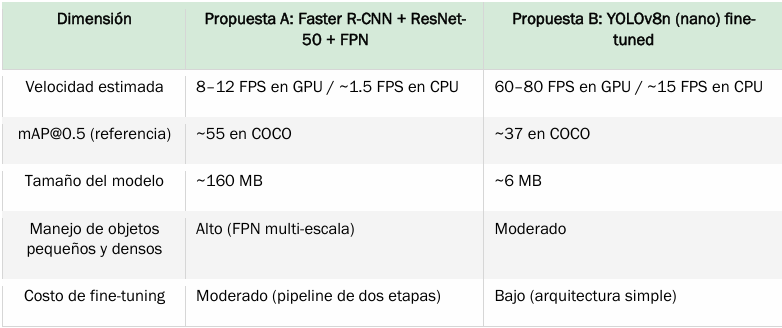

Responda en su reporte:

1. Tomando en cuenta las restricciones operativas de VisorShelf (hardware sin GPU, latencia < 500 ms, anaqueles densos), ¿cuál propuesta recomendaría y por qué? No se limite a comparar los números de la tabla; argumente la lógica de la decisión conectándola con las características técnicas de cada arquitectura.

R// Considerando que el sistema debe operar sin GPU y con una restricción de latencia estricta, la mejor opción es YOLOv8n. Aunque su precisión es menor que la de Faster R-CNN, su velocidad en CPU es significativamente mayor y cumple con el requerimiento de procesamiento en tiempo real. En un entorno operativo, es más importante garantizar que el sistema responda de forma consistente que maximizar la precisión a costa de tiempos de respuesta demasiado altos.

2. Si VisorShelf logra instalar una GPU de gama media (RTX 3060) en las tiendas flagship, ¿cambiaría su recomendación? Explique cómo ese cambio de hardware altera el trade-off entre las dos propuestas. 

R// Si se introduce una GPU como una RTX 3060, la decisión cambia, ya que Faster R-CNN pasa a ser mucho más viable en términos de velocidad. En ese escenario, su mejor desempeño en objetos pequeños y densos, especialmente usando FPN, se vuelve una ventaja importante para el contexto de anaqueles, donde los productos suelen estar muy juntos.

3. ¿Qué riesgo técnico específico introduce hacer fine-tuning de Faster R-CNN con un dataset de anaqueles sin aplicar learning rate diferenciado entre el backbone y las capas nuevas? ¿Cómo se llama ese fenómeno y cómo lo mitigaría?

R// Un riesgo importante al hacer fine-tuning de Faster R-CNN sin usar learning rate diferenciado es que el backbone pierda el conocimiento aprendido previamente, lo que se conoce como catastrophic forgetting. Esto ocurre cuando los pesos preentrenados se modifican demasiado rápido y el modelo deja de generalizar bien. Para evitarlo, se recomienda usar una tasa de aprendizaje menor en el backbone o congelarlo inicialmente y ajustar primero las capas nuevas antes de afinar todo el modelo de manera progresiva.